In [4]:
import torch
from torch.utils.data import Dataset
from torchvision import datasets
from torchvision.transforms import v2
import matplotlib.pyplot as plt

training_data = datasets.FashionMNIST(
    root="../data",
    train=True,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
)

test_data = datasets.FashionMNIST(
    root="../data",
    train=False,
    download=True,
    transform=(v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)]))
)

100.0%
100.0%
100.0%
100.0%


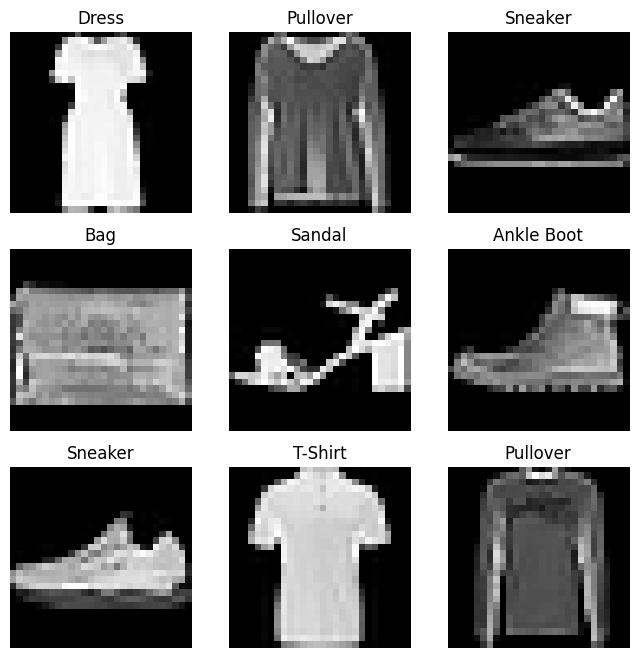

In [ ]:
labels_map = {
    0: "T-Shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot",
}

figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3

for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(training_data), size=(1,)).item()
    img, label = training_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis("off")
    # img.squeeze() 불필요한 차원 제거
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

In [ ]:
import os
import pandas as pd
from torchvision.io import decode_image

class CustomImageDataset(Dataset):
    def __init__(self, annotations_file, img_dir, transform=None, target_transform=None):
        self.img_labels = pd.read_csv(annotations_file)
        # 이미지 폴더 경로 저장
        self.img_dir = img_dir
        # 이미지 전처리 함수 저장
        self.transform = transform
        # label 전처리 함수 저장
        self.target_transform = target_transform

    # 데이터 개수 반환
    def __len__(self):
        return len(self.img_labels)
    
    def __getitem__(self, idx):
        # 이미지 파일 경로 생성
        img_path = os.path.join(self.img_dir, self.img_labels.iloc[idx, 0])
        # 이미지 파일 읽어서 tensor로 변환
        image = decode_image(img_path)
        # label 가져오기
        label = self.img_labels.iloc[idx, 1]
        # 이미지 전처리 수행
        if self.transform:
            image = self.transform(image)
        # label 전처리 수행
        if self.target_transform:
            label = self.target_transform(label)
        # (이미지, 정답) 반환
        return image, label

In [9]:
# DataLoaders를 사용해서 학습용 데이터 준비하기
from torch.utils.data import DataLoader

train_dataloader = DataLoader(training_data, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=64, shuffle=True)

Feature batch shape: torch.Size([64, 1, 28, 28])
Labels batch shape: torch.Size([64])


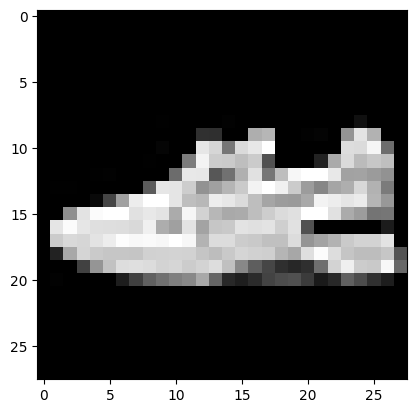

Label: 7


In [ ]:
# train_dataloader에서 첫 번째 배치를 가져온다
train_features, train_labels = next(iter(train_dataloader))
print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels.size()}")

# 첫 번째 이미지 선택
# [1, 28, 28] -> [28, 28] (채널 차원 제거)
img = train_features[0].squeeze()
# 첫 번째 이미지의 정답 가져오기
label = train_labels[0]

plt.imshow(img, cmap="gray")
plt.show()
print(f"Label: {label}")